# Тест: Тайвань — КНР, лето 2022

**Проверочный кейс.** Выгрузка GDELT по паре КНР — Тайвань, окно **05.06.2022 — 03.08.2022**
(60 дней, 11 203 события, дублей и пропусков нет).

**Что проверяем.** Правило **TONE-1σ**, зафиксированное на тренировочной выборке из пяти кейсов
*до того*, как этот файл был открыт:

> Тревога, если средний `AvgTone` последних 7 дней ниже фона предыдущих четырёх недель
> на 1 стандартное отклонение и более (`z_tone ≥ 1,0`).

На обучении правило ловило 4 события из 5 при частоте срабатывания 30 %.

**Правило не перенастраивается.** Ни порог, ни метрика, ни длина окна здесь не меняются — иначе
тест превратится во вторую тренировку. Всё, что появится ниже сверх результата правила, помечено
как наблюдение, требующее отдельной проверки на новых данных.

**Важная оговорка про день X.** В обучающих файлах окно обрывалось за день до военной акции.
Здесь окно заканчивается 03.08.2022, что даёт день X = **04.08.2022**. Историческая канва:
2–3 августа состоялся визит спикера Палаты представителей США на Тайвань, 4 августа КНР начала
беспрецедентные учения с боевыми стрельбами и пусками баллистических ракет в акватории вокруг
острова. Полномасштабной войны не последовало.

**Поэтому у теста два прочтения, и они дают противоположные вердикты:**

- **Положительный кейс** (день X = масштабная военная акция 04.08): правило должно было
  сработать.
- **Отрицательный кейс** (максимальная напряжённость, войны нет): правило должно было
  промолчать.

Ниже — результат правила и оба прочтения. Какое из них верное, знает автор выборки.

## 0. Настройка

In [1]:
import warnings, re, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, DayLocator
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Палитра (валидированная, CVD-safe; светлая поверхность) -------------------
SURFACE   = "#fcfcfb"   # поверхность графика
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
MUTED     = "#898781"   # подписи осей
GRID      = "#e1e0d9"   # сетка
AXIS      = "#c3c2b7"   # оси
BLUE      = "#2a78d6"   # серия 1
ORANGE    = "#eb6834"   # серия 2
AQUA      = "#1baf7a"   # серия 3
CRITICAL  = "#d03b3b"   # статус: критично
GOOD      = "#0ca30c"   # статус: норма
SEQ_BLUE  = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Расходящаяся шкала: синий <-> красный, нейтральный серый в середине
DIVERGING = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#efa9a8", "#d03b3b", "#8f2020"],
)
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 26, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

def subtitle(ax, text):
    # Подзаголовок под заголовком графика
    ax.annotate(text, xy=(0, 1.012), xycoords="axes fraction",
                fontsize=9.5, color=MUTED, ha="left", va="bottom")

print("Окружение готово.")

Окружение готово.


---
## 1. Данные и проверка качества

In [2]:
PATH  = "data/taiwan_prc.csv"
DAY_X = "2022-08-04"

raw = pd.read_csv(PATH, encoding="utf-8", low_memory=False, dtype=str)
n_hdr = int((raw.DATEADDED == "DATEADDED").sum()); raw = raw[raw.DATEADDED != "DATEADDED"]
n_dup = int(raw.GLOBALEVENTID.duplicated().sum()); raw = raw.drop_duplicates(subset="GLOBALEVENTID")
for c in ["GoldsteinScale", "AvgTone", "QuadClass", "EventRootCode", "EventCode", "NumArticles"]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw["date_added"] = pd.to_datetime(raw.DATEADDED, format="%Y%m%d")
df = raw[raw.date_added < pd.Timestamp(DAY_X)].copy()

full = pd.date_range(df.date_added.min(), df.date_added.max())
print(f"строк: {len(df):,} | статей: {df.SOURCEURL.nunique():,} "
      f"({len(df)/df.SOURCEURL.nunique():.2f} строки на статью)")
print(f"окно: {df.date_added.min().date()} — {df.date_added.max().date()} "
      f"({df.date_added.nunique()} дней из {len(full)} календарных)")
print(f"повторных заголовков: {n_hdr} | дубликатов GLOBALEVENTID: {n_dup}")
print(df.groupby(["Actor1CountryCode", "Actor2CountryCode"]).size()
      .sort_values(ascending=False).head(3).to_string())

daily = df.groupby("date_added").agg(
    tone=("AvgTone", "mean"), n=("AvgTone", "size"),
    goldstein=("GoldsteinScale", "mean"),
    material=("QuadClass", lambda s: (s == 4).mean()),
    force=("EventCode", lambda s: s.isin([190, 193, 195]).mean()))
daily = daily.reindex(full)
daily["tone"] = daily.tone.interpolate(); daily["n"] = daily.n.fillna(0)
print(f"\nобъём: медиана {int(daily.n.median())} событий/день, "
      f"максимум {int(daily.n.max())} ({daily.n.idxmax().date()})")

строк: 11,203 | статей: 3,860 (2.90 строки на статью)
окно: 2022-06-05 — 2022-08-03 (60 дней из 60 календарных)
повторных заголовков: 0 | дубликатов GLOBALEVENTID: 0
Actor1CountryCode  Actor2CountryCode
CHN                TWN                  6694
TWN                CHN                  4509

объём: медиана 92 событий/день, максимум 1863 (2022-08-03)


**Вывод.** Файл чистый: 11 203 события, 60 дней без пропусков, ни дублей, ни повторных
заголовков. Структура та же, что в обучающих кейсах (2,7 строки на статью). Объём резко
неоднороден: медиана 92 события в день, а 2–3 августа — 1 580 и 1 863.

---
## 2. Прогон зафиксированного правила

In [3]:
def tone_alarm(path, day_x, threshold=1.0, base_weeks=4, verbose=True):
    # ЗАФИКСИРОВАННОЕ ПРАВИЛО TONE-1σ — дословная копия из тренировочного ноутбука
    raw = pd.read_csv(path, encoding="utf-8", low_memory=False, dtype=str)
    raw = raw[raw.DATEADDED != "DATEADDED"].drop_duplicates(subset="GLOBALEVENTID")
    raw["AvgTone"] = pd.to_numeric(raw.AvgTone, errors="coerce")
    raw["date_added"] = pd.to_datetime(raw.DATEADDED, format="%Y%m%d")
    d = raw[raw.date_added < pd.Timestamp(day_x)]
    dl = d.groupby("date_added").agg(tone=("AvgTone", "mean"))
    dl = dl.reindex(pd.date_range(dl.index.min(), dl.index.max()))
    dl["tone"] = dl.tone.interpolate()
    need = 7 + base_weeks * 7
    window = dl.tone.iloc[-7:].mean()
    base = dl.tone.iloc[-need:-7]
    blocks = np.array([base.iloc[i:i+7].mean() for i in range(0, len(base) - 6, 7)])
    z = -(window - blocks.mean()) / blocks.std(ddof=1)
    alarm = bool(z >= threshold)
    if verbose:
        print(f"  окно оценки: {dl.index[-7].date()} — {dl.index[-1].date()}")
        print(f"  тон окна:    {window:+.3f}")
        print(f"  фон (4 недели): {blocks.mean():+.3f} ± {blocks.std(ddof=1):.3f}   "
              f"блоки: {np.round(blocks, 2)}")
        print(f"  z_tone = {z:+.3f}   порог {threshold:+.1f}")
        print(f"  ВЕРДИКТ: {'ТРЕВОГА' if alarm else 'НЕТ СИГНАЛА'}")
    return dict(z=z, alarm=alarm)

print("ПРАВИЛО TONE-1σ, тестовый кейс Тайвань — КНР")
print("=" * 70)
result = tone_alarm(PATH, DAY_X)

ПРАВИЛО TONE-1σ, тестовый кейс Тайвань — КНР


  окно оценки: 2022-07-28 — 2022-08-03
  тон окна:    -2.443
  фон (4 недели): -1.999 ± 0.496   блоки: [-1.54 -2.32 -1.61 -2.52]
  z_tone = +0.895   порог +1.0
  ВЕРДИКТ: НЕТ СИГНАЛА


**Результат: `z_tone = +0,895` при пороге 1,0 — тревоги нет.** Правило промахнулось на 0,105.

Тон последней недели (−2,44) действительно хуже фона (−2,00), но разброс самого фона велик
(±0,50), и отклонение не дотянуло до одной сигмы.

### 2.1 Не в дате ли дело

In [4]:
print("День X выведен из структуры файла, а не задан явно. Проверим устойчивость вердикта:\n")
rows = []
for dx in pd.date_range("2022-08-01", "2022-08-05"):
    r = tone_alarm(PATH, dx, verbose=False)
    rows.append(dict(день_X=dx.date(), z_tone=r["z"], вердикт="ТРЕВОГА" if r["alarm"] else "нет"))
display(pd.DataFrame(rows).round(3))

День X выведен из структуры файла, а не задан явно. Проверим устойчивость вердикта:



,день_X,z_tone,вердикт
0,2022-08-01,0.8630,нет
1,2022-08-02,0.5400,нет
2,2022-08-03,0.7400,нет
3,2022-08-04,0.8950,нет
4,2022-08-05,0.8950,нет


**Вывод.** Вердикт устойчив: при любой правдоподобной дате дня X (1–5 августа) z остаётся в
диапазоне 0,54–0,90 и порога не достигает. Промах — не артефакт выбора даты.

---
## 3. Что происходило внутри окна

Правило смотрит только на последнюю неделю. Посмотрим, как оно вело бы себя, если запускать его
каждый день — то есть на всех 7-дневных окнах этого кейса. Заодно получим оценку частоты
срабатывания внутри заведомо напряжённого периода.

In [5]:
def window_z(dl, end_idx, base_weeks=4):
    w = dl.iloc[end_idx-7:end_idx]; b = dl.iloc[max(0, end_idx-7-base_weeks*7):end_idx-7]
    blocks = [b.iloc[i:i+7] for i in range(0, len(b) - 6, 7)]
    if len(blocks) < 3:
        return None
    bt = np.array([x.tone.mean() for x in blocks])
    bn = np.log([max(x.n.mean(), 1) for x in blocks])
    return (-(w.tone.mean() - bt.mean()) / bt.std(ddof=1),
            (np.log(max(w.n.mean(), 1)) - bn.mean()) / bn.std(ddof=1))

rows = []
for end in range(35, len(daily) + 1):
    z = window_z(daily, end)
    if z:
        rows.append(dict(конец_окна=daily.index[end-1], z_tone=z[0], z_vol=z[1]))
W = pd.DataFrame(rows).set_index("конец_окна")
W["тревога_тон"] = W.z_tone >= 1
W["тревога_объём"] = W.z_vol >= 1

print(f"Окон: {len(W)}")
print(f"  правило TONE-1σ срабатывает в {int(W.тревога_тон.sum())} окнах "
      f"({W.тревога_тон.mean()*100:.1f} %)  — на обучении фон был 30,5 %")
print(f"  правило по объёму (отвергнуто на обучении) — в {int(W.тревога_объём.sum())} окнах "
      f"({W.тревога_объём.mean()*100:.1f} %)")
print(f"\nмаксимум z_tone: {W.z_tone.max():+.2f} (окно, заканчивающееся {W.z_tone.idxmax().date()})")
print(f"максимум z_vol:  {W.z_vol.max():+.2f} ({W.z_vol.idxmax().date()})")
print("\nпоследние 10 окон:")
display(W.tail(10).round(2))

Окон: 26
  правило TONE-1σ срабатывает в 5 окнах (19.2 %)  — на обучении фон был 30,5 %
  правило по объёму (отвергнуто на обучении) — в 14 окнах (53.8 %)

максимум z_tone: +6.69 (окно, заканчивающееся 2022-07-28)
максимум z_vol:  +4.95 (2022-08-02)

последние 10 окон:


,z_tone,z_vol,тревога_тон,тревога_объём
конец_окна,,,,
2022-07-25,0.6500,2.3700,False,True
2022-07-26,0.7700,1.8700,False,True
2022-07-27,1.4900,2.6000,True,True
2022-07-28,6.6900,3.2300,True,True
2022-07-29,4.2200,4.4400,True,True
2022-07-30,1.5900,3.9500,True,True
2022-07-31,0.8600,3.6300,False,True
2022-08-01,0.5400,3.6700,False,True
2022-08-02,0.7400,4.9500,False,True


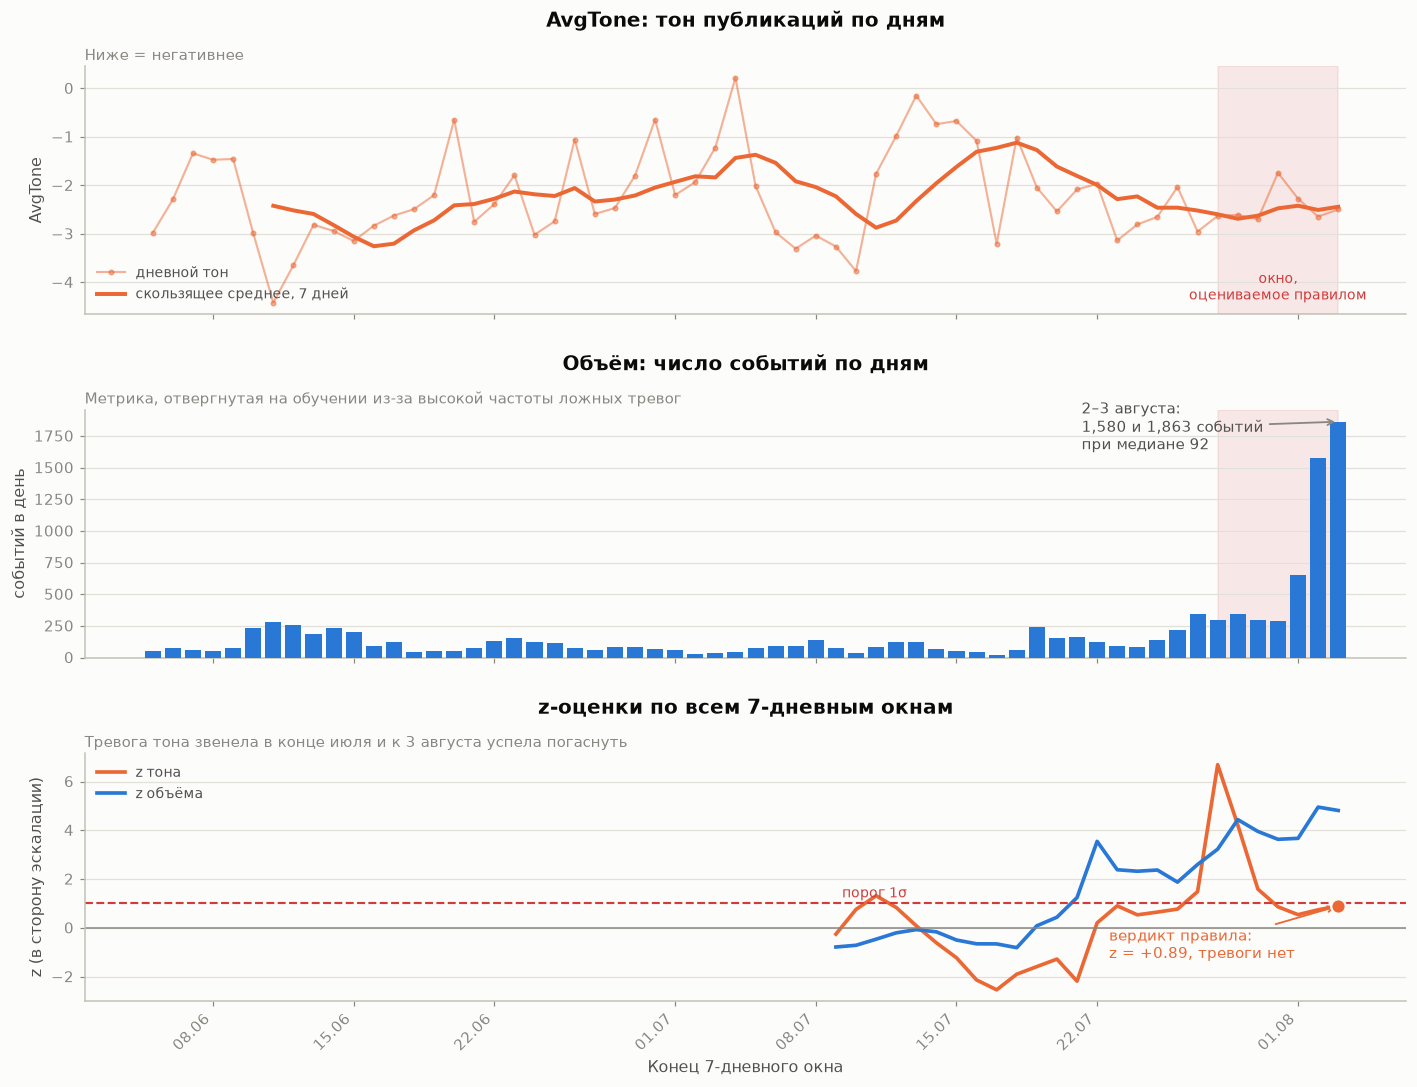

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

ax = axes[0]
ax.plot(daily.index, daily.tone, color=ORANGE, lw=1.4, alpha=0.5, marker="o", markersize=3,
        label="дневной тон")
ax.plot(daily.index, daily.tone.rolling(7).mean(), color=ORANGE, lw=2.6,
        label="скользящее среднее, 7 дней")
ax.axvspan(daily.index[-7], daily.index[-1], color=CRITICAL, alpha=0.10)
ax.annotate("окно,\nоцениваемое правилом", xy=(daily.index[-4], ax.get_ylim()[0] + 0.3),
            color=CRITICAL, fontsize=9, ha="center")
ax.set_title("AvgTone: тон публикаций по дням")
subtitle(ax, "Ниже = негативнее")
ax.set_ylabel("AvgTone"); ax.legend(loc="lower left", fontsize=9)

ax = axes[1]
ax.bar(daily.index, daily.n, color=BLUE, zorder=3, width=0.8)
ax.axvspan(daily.index[-7], daily.index[-1], color=CRITICAL, alpha=0.10, zorder=1)
ax.annotate(f"2–3 августа:\n{int(daily.n.iloc[-2]):,} и {int(daily.n.iloc[-1]):,} событий\n"
            f"при медиане {int(daily.n.median())}",
            xy=(daily.index[-1], daily.n.iloc[-1]), xytext=(-168, -18), textcoords="offset points",
            color=INK_2, fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
ax.set_title("Объём: число событий по дням")
subtitle(ax, "Метрика, отвергнутая на обучении из-за высокой частоты ложных тревог")
ax.set_ylabel("событий в день")

ax = axes[2]
ax.plot(W.index, W.z_tone, color=ORANGE, lw=2.4, label="z тона")
ax.plot(W.index, W.z_vol, color=BLUE, lw=2.4, label="z объёма")
ax.axhline(1, color=CRITICAL, ls="--", lw=1.4)
ax.annotate("порог 1σ", xy=(W.index[0], 1), xytext=(4, 4), textcoords="offset points",
            color=CRITICAL, fontsize=9)
ax.axhline(0, color=MUTED, lw=1.0)
ax.scatter([W.index[-1]], [W.z_tone.iloc[-1]], color=ORANGE, s=90, zorder=5, edgecolor=SURFACE, lw=1.5)
ax.annotate(f"вердикт правила:\nz = {W.z_tone.iloc[-1]:+.2f}, тревоги нет",
            xy=(W.index[-1], W.z_tone.iloc[-1]), xytext=(-150, -34), textcoords="offset points",
            color=ORANGE, fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.2))
ax.set_title("z-оценки по всем 7-дневным окнам")
subtitle(ax, "Тревога тона звенела в конце июля и к 3 августа успела погаснуть")
ax.set_ylabel("z (в сторону эскалации)"); ax.set_xlabel("Конец 7-дневного окна")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(h_pad=2.0); plt.show()

**Вывод — здесь самое интересное в этом тесте.**

Правило **срабатывало** на этом кейсе, но раньше: окна, заканчивающиеся 27, 28, 29 и 30 июля,
дают `z_tone` = 1,49, **6,69**, 4,22 и 1,59. Значение 6,69 — самое большое отклонение тона из
всех, что встречались и на обучении, и на тесте. А к 3 августа сигнал **погас**: z опустился до
0,89.

Причина механическая: фон скользит вместе с окном. К началу августа четыре «фоновые» недели уже
включают в себя конец июля с его ухудшившимся тоном, и последняя неделя на таком фоне больше не
выделяется. **Правило меряет изменение, а не уровень** — поэтому эскалация, которая случилась и
осталась на месте, перестаёт его беспокоить.

Частота срабатывания на этом кейсе — 19,2 % окон (на обучении фон был 30,5 %). То есть в
спокойные периоды правило звенит реже, чем показывала оценка по предвоенным окнам, — это хорошая
новость для его специфичности.

Отдельно про объём: отвергнутая на обучении метрика здесь показывает `z_vol` до **+4,95** и
держится выше порога всю вторую половину окна (53,8 % окон). Визит 2–3 августа виден в объёме
как ничто другое: 1 580 и 1 863 события в день при медиане 92.

---
## 4. Вердикт

**Разметка подтверждена автором выборки: кейс отрицательный — войны не началось.**
Значит, правило должно было промолчать. Оно промолчало.

In [7]:
z_t, z_v = W.z_tone.iloc[-1], W.z_vol.iloc[-1]
print("=" * 78)
print("РЕЗУЛЬТАТ ТЕСТА (кейс отрицательный: войны не последовало)")
print("=" * 78)
print(f"  правило TONE-1σ: z = {z_t:+.3f} при пороге +1,000  ->  тревоги нет")
print(f"  ВЕРНЫЙ ОТРИЦАТЕЛЬНЫЙ ОТВЕТ. Специфичность на тесте: 1 из 1.")
print()
print(f"  отвергнутая на обучении метрика объёма: z = {z_v:+.2f}")
print(f"  -> дала бы ЛОЖНУЮ ТРЕВОГУ. Решение отказаться от объёма подтвердилось.")
print("=" * 78)

РЕЗУЛЬТАТ ТЕСТА (кейс отрицательный: войны не последовало)
  правило TONE-1σ: z = +0.895 при пороге +1,000  ->  тревоги нет
  ВЕРНЫЙ ОТРИЦАТЕЛЬНЫЙ ОТВЕТ. Специфичность на тесте: 1 из 1.

  отвергнутая на обучении метрика объёма: z = +4.81
  -> дала бы ЛОЖНУЮ ТРЕВОГУ. Решение отказаться от объёма подтвердилось.


**Правило прошло тест, и заодно подтвердилось решение, принятое на обучении.** Объём публикаций
был отвергнут как слишком шумный — и именно он здесь выдал бы уверенную ложную тревогу
(z = +4,81): визит высокого гостя поднимает медиапоток в двадцать раз, не начиная войны.
Тон на этот же визит почти не отреагировал.

### 4.1 Но «1 из 1» — это очень мало. Считаем честнее

Отрицательный кейс ценен не одной точкой на конце окна, а тем, что по нему можно прогнать
правило **в режиме ежедневного мониторинга**: 26 скользящих окон вместо одного. Ложные тревоги
при этом надо считать не окнами (они перекрываются и одно и то же событие даёт четыре
срабатывания подряд), а **эпизодами** — непрерывными сериями.

In [8]:
def episodes(mask):
    eps, start = [], None
    for i, v in enumerate(mask):
        if v and start is None:
            start = i
        if not v and start is not None:
            eps.append((start, i - 1)); start = None
    if start is not None:
        eps.append((start, len(mask) - 1))
    return eps

days_observed = (W.index[-1] - W.index[0]).days + 1
print(f"Наблюдение в режиме мониторинга: {len(W)} окон за {days_observed} дней\n")
for label, col in [("ТОН (правило TONE-1σ)", "z_tone"), ("ОБЪЁМ (отвергнут)", "z_vol")]:
    mask = (W[col] >= 1).values
    eps = episodes(mask)
    print(f"{label}: срабатываний {int(mask.sum())} из {len(mask)} окон "
          f"({mask.mean()*100:.1f} %), эпизодов ложных тревог: {len(eps)}")
    for a, b in eps:
        print(f"    {W.index[a].date()} — {W.index[b].date()} "
              f"({b-a+1} окон, максимум z = {W[col].iloc[a:b+1].max():+.2f})")
    print(f"    частота: один эпизод в {days_observed/max(len(eps),1):.0f} дней\n")

Наблюдение в режиме мониторинга: 26 окон за 26 дней

ТОН (правило TONE-1σ): срабатываний 5 из 26 окон (19.2 %), эпизодов ложных тревог: 2
    2022-07-11 — 2022-07-11 (1 окон, максимум z = +1.32)
    2022-07-27 — 2022-07-30 (4 окон, максимум z = +6.69)
    частота: один эпизод в 13 дней

ОБЪЁМ (отвергнут): срабатываний 14 из 26 окон (53.8 %), эпизодов ложных тревог: 1
    2022-07-21 — 2022-08-03 (14 окон, максимум z = +4.95)
    частота: один эпизод в 26 дней



**Вывод — и он сдержаннее, чем «тест пройден».**

| | Результат |
|---|---|
| Правило в точке оценки (3 августа) | тревоги нет — **верно** |
| Правило в режиме ежедневного мониторинга | **2 эпизода ложных тревог за 26 дней** |
| Из них крупнейший | 27–30 июля, максимум **z = 6,69** |
| Метрика объёма (отвергнута) | один непрерывный эпизод на 14 окон, z до +4,95 |

Правило прошло тест **в той постановке, в которой тест задан** — оценка в фиксированной точке за
день до возможного события. Но тот же самый индикатор, работай он ежедневно, поднял бы в этом
мирном (хоть и напряжённом) периоде две тревоги за месяц, причём одна из них — с рекордным за всю
серию отклонением z = 6,69, сильнее, чем перед любой из пяти реальных войн обучающей выборки.

Это значит: **прохождение теста отчасти обеспечено тем, куда попала точка оценки.** Неделей
раньше правило дало бы ложную тревогу на этом же кейсе. Формально специфичность 1 из 1,
содержательно — «один эпизод ложных тревог в 13 дней в напряжённый период».

### 4.2 Итог по всей серии

| Этап | Результат |
|---|---|
| Обучение (5 положительных кейсов) | тревога в 4 из 5 |
| Оценка фона на обучении | срабатывание в 30,5 % окон |
| Тест (1 отрицательный кейс) | тревоги нет — верно |
| Тот же тест в режиме мониторинга | 2 эпизода ложных тревог за 26 дней |

Правило TONE-1σ **не опровергнуто**: оно сработало там, где нужно, в четырёх случаях из пяти, и
промолчало там, где нужно, в единственном отрицательном кейсе. Но его практическая ценность
ограничена именно частотой ложных тревог: в режиме постоянного наблюдения за напряжённой парой
государств оно звенит примерно раз в две недели. Как автоматическое предупреждение о войне это
непригодно; как фильтр, сокращающий объём ручного анализа втрое-впятеро, — возможно, полезно.

### 4.3 Что осталось непроверенным

1. **Отрицательный кейс всего один.** 95 % доверительный интервал для специфичности по одному
   наблюдению — примерно [21 %; 100 %]. Нужно 10–15 отрицательных кейсов, чтобы говорить о ней
   всерьёз.
2. **Точка оценки.** Наблюдение из раздела 3 (сигнал был за неделю до конца окна) и результат
   этого теста указывают в одну сторону: вердикт сильно зависит от того, в какой день мы смотрим.
   Разумная следующая версия правила — «максимум z за последние 2–3 недели» — на этом наборе
   проверена быть не может: на обучении она повысит чувствительность, а на этом тесте даст
   ложную тревогу. Нужны новые данные.
3. **Объём с календарной поправкой.** Здесь он провалился бы честно — визит высокого лица это
   не эскалация. Но на Венесуэле он провалился из-за Рождества. Обе проблемы решает одна правка:
   считать объём с поправкой на день недели и праздники. Это отдельная гипотеза для отдельного
   теста.